<a href="https://colab.research.google.com/github/anvitha1267/spending-pattern-analysis/blob/main/anomaly_detection_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# Anomaly Detection Demo

## Section 1: Generate Synthetic Time Series Spending Data

Generates 100 synthetic budget time series from 2005–2025 with the following properties:

- **Starting value**: random draw from $0–$90 M (uniform), set in 2005
- **Annual drift**: ±1–3% per year (random direction each year)
- **Change points (~1 in 10 series)**: one year gets a ±40–60% abrupt shift
  - Half of those change points land in the most recent year (2025)

Output is stored in long-format (`entity_id`, `year`, `budget_millions`) — the standard layout for time series / anomaly detection libraries.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

YEARS = list(range(2005, 2026))  # 2005 to 2025

records = []

for i in range(100):
    entity_id = f"entity_{i + 1}"

    # Each entity starts with a random budget between $0M and $90M
    budget = np.random.uniform(0, 90)

    # About 1 in 10 entities will have a sudden large spending change
    has_change_point = np.random.random() < 0.10
    change_year = None

    if has_change_point:
        if np.random.random() < 0.50:
            change_year = 2025                           # anomaly in the most recent year
        else:
            change_year = np.random.randint(2006, 2025)  # anomaly somewhere in history

    for year in YEARS:
        if year == change_year:
            # Sudden large change: between +40% and +60%, or -40% to -60%
            shock = np.random.uniform(0.40, 0.60)
            if np.random.random() < 0.5:
                shock = -shock
            budget = budget * (1 + shock)
        elif year > 2005:
            # Normal year: small drift between 1% and 3%, up or down
            drift = np.random.uniform(0.01, 0.03)
            if np.random.random() < 0.5:
                drift = -drift
            budget = budget * (1 + drift)

        records.append({
            "entity_id": entity_id,
            "year": year,
            "budget_millions": round(budget, 2),
            "has_change_point": has_change_point,
            "change_year": change_year,
        })

df = pd.DataFrame(records)

# One row per entity — useful for looking up each entity's change point info
meta = (df.drop_duplicates("entity_id")
          [["entity_id", "has_change_point", "change_year"]]
          .reset_index(drop=True))

print(f"Generated {df.entity_id.nunique()} series × {len(YEARS)} years = {len(df)} rows")
print(f"  No change point:  {(~meta.has_change_point).sum()}")
print(f"  Historical CP:    {(meta.has_change_point & (meta.change_year < 2025)).sum()}")
print(f"  Most-recent CP:   {(meta.change_year == 2025).sum()}")
df.head(6)

Generated 100 series × 21 years = 2100 rows
  No change point:  95
  Historical CP:    2
  Most-recent CP:   3


,entity_id,year,budget_millions,has_change_point,change_year
0,entity_1,2005,33.71,False,NaN
1,entity_1,2006,34.54,False,NaN
2,entity_1,2007,34.09,False,NaN
3,entity_1,2008,34.47,False,NaN
4,entity_1,2009,35.23,False,NaN
5,entity_1,2010,35.59,False,NaN


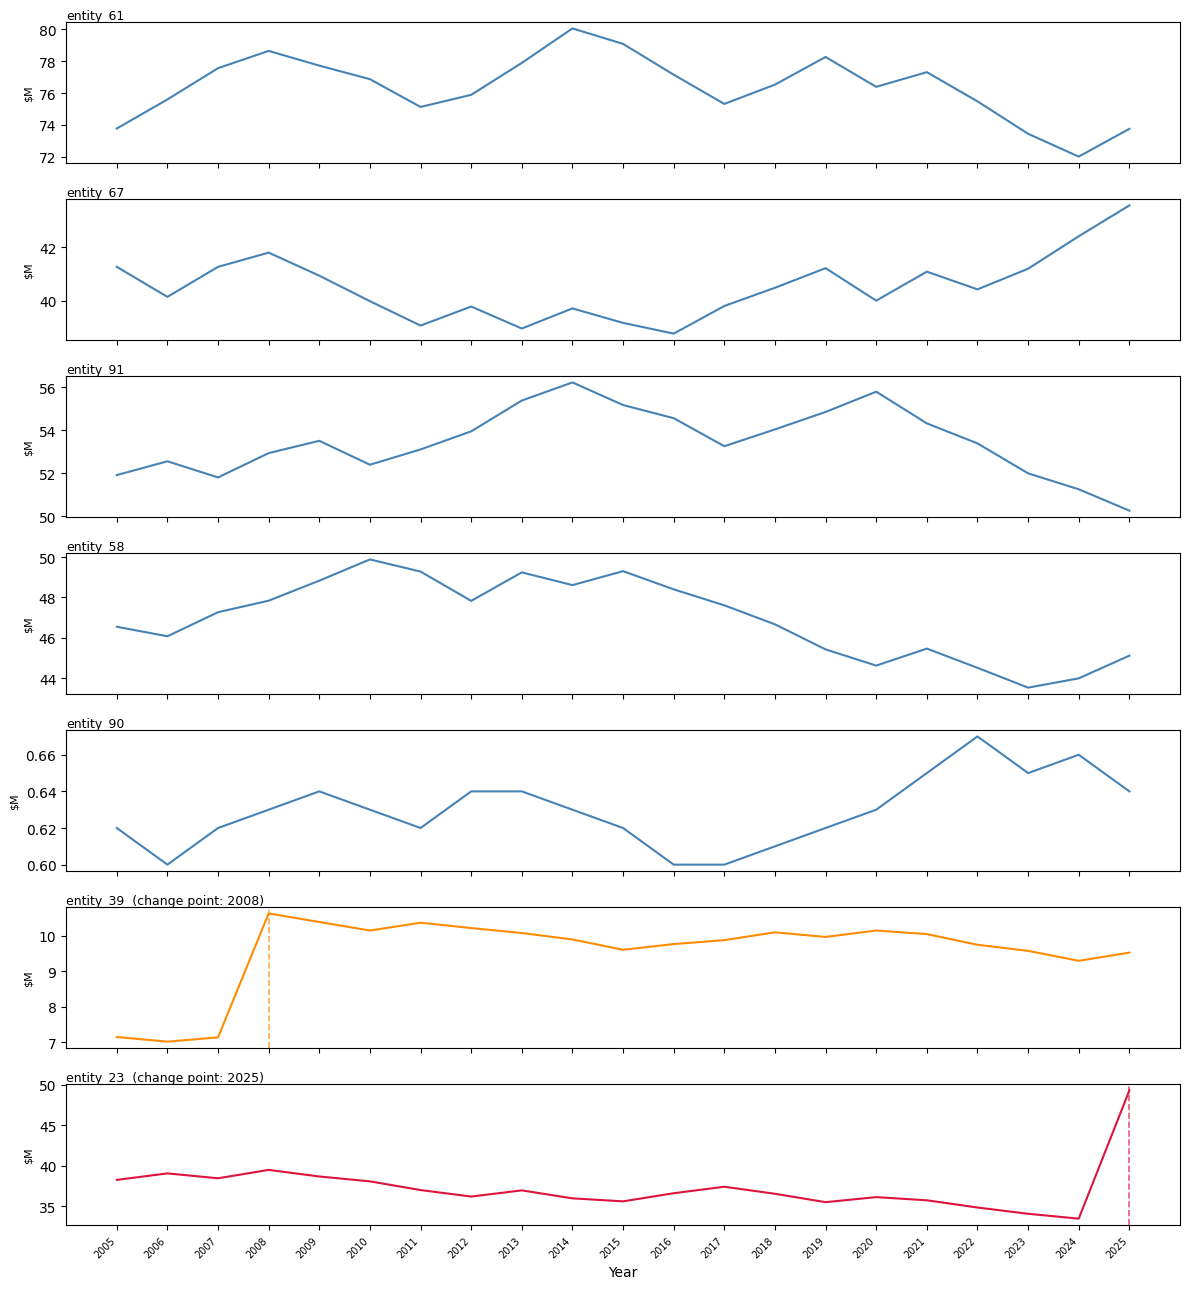

In [30]:
# Pick 5 normal series, 1 historical change-point, 1 most-recent change-point
rng = np.random.default_rng(7)

normal_ids    = meta.loc[~meta.has_change_point, "entity_id"].values
hist_cp_ids   = meta.loc[meta.has_change_point & (meta.change_year < 2025), "entity_id"].values
recent_cp_ids = meta.loc[meta.change_year == 2025, "entity_id"].values

sample_ids = (
    list(rng.choice(normal_ids, size=5, replace=False)) +
    list(rng.choice(hist_cp_ids, size=1)) +
    list(rng.choice(recent_cp_ids, size=1))
)

fig, axes = plt.subplots(7, 1, figsize=(12, 13), sharex=True)

for ax, eid in zip(axes, sample_ids):
    series = df[df.entity_id == eid]
    info   = meta[meta.entity_id == eid].iloc[0]

    # Color by type: blue = normal, orange = historical CP, red = 2025 CP
    if not info.has_change_point:
        color = "steelblue"
    elif info.change_year == 2025:
        color = "crimson"
    else:
        color = "darkorange"

    ax.plot(series.year, series.budget_millions, color=color, lw=1.5)

    if info.has_change_point:
        ax.axvline(info.change_year, color=color, lw=1.2, ls="--", alpha=0.7)
        ax.set_title(f"{eid}  (change point: {int(info.change_year)})", fontsize=9, loc="left", pad=2)
    else:
        ax.set_title(eid, fontsize=9, loc="left", pad=2)

    ax.set_ylabel("$M", fontsize=8)

axes[-1].set_xlabel("Year")
axes[-1].set_xticks(YEARS)
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

## Section 2: Isolation Forest

**Isolation Forest** detects anomalies by randomly partitioning the feature space with decision trees. Points that are easy to isolate (short average path length) are flagged as anomalies — intuitively, outliers need fewer splits to be separated from the crowd.

**Steps:**
1. Engineer features that capture abnormal year-over-year change
2. Fit the forest on all 100 series so it learns what "normal drift" looks like
3. Score every (entity, year) observation — more negative score = more anomalous
4. Visualize scores for our 7 sample series alongside ground-truth change points

In [31]:
from sklearn.ensemble import IsolationForest

# --- Step 1: Compute features ---
# We describe each (entity, year) with two numbers the model can learn from:
#
#   yoy_change   — how much spending changed vs. last year, as a percentage
#                  Normal years are ±1–3%.  Anomalous years are ±40–60%.
#
#   value_zscore — how unusual this year's value is within that entity's history
#                  0 = average, ±2 = quite unusual, ±3 = very unusual

feat = df.sort_values(["entity_id", "year"]).copy()

# Year-over-year % change using the previous year's value
feat["prev_budget"] = feat.groupby("entity_id")["budget_millions"].shift(1)
feat["yoy_change"]  = (feat["budget_millions"] - feat["prev_budget"]) / feat["prev_budget"] * 100

# Z-score per entity: (value - entity mean) / entity std deviation
feat["value_zscore"] = 0.0
for eid in feat.entity_id.unique():
    mask = feat.entity_id == eid
    vals = feat.loc[mask, "budget_millions"]
    feat.loc[mask, "value_zscore"] = (vals - vals.mean()) / vals.std()

# Drop 2005 — it has no prior year to compare against
feat = feat.dropna(subset=["yoy_change"]).copy()

features = feat[["yoy_change", "value_zscore"]].values  # the array the model will train on

print(f"Feature table: {len(feat)} rows  ({feat.entity_id.nunique()} entities × 20 years)")
feat[["entity_id", "year", "budget_millions", "yoy_change", "value_zscore"]].head(6)

Feature table: 2000 rows  (100 entities × 20 years)


,entity_id,year,budget_millions,yoy_change,value_zscore
1,entity_1,2006,34.54,2.462177,0.846662
2,entity_1,2007,34.09,-1.302837,0.377122
3,entity_1,2008,34.47,1.114696,0.773622
4,entity_1,2009,35.23,2.204816,1.566623
5,entity_1,2010,35.59,1.021856,1.942254
6,entity_1,2011,34.64,-2.669289,0.951004


In [32]:
# --- Step 2: Fit the Isolation Forest ---
# contamination tells the model what fraction of data to treat as anomalies.
# We planted ~11 change points in 2000 observations (~0.5%), so we set it to 1%
# to give the model a bit of extra sensitivity.

model_if = IsolationForest(n_estimators=300, contamination=0.01, random_state=42)
model_if.fit(features)

# --- Step 3: Score each observation ---
# decision_function gives a score per row:
#   negative score → point was easy to isolate → likely an anomaly
#   positive score → point blends in with the crowd → likely normal
feat["if_score"] = model_if.decision_function(features)
feat["if_flag"]  = model_if.predict(features)          # -1 = anomaly, 1 = normal

print(f"Flagged {(feat.if_flag == -1).sum()} anomalies out of {len(feat)} observations")
print()
print("Did IF find the planted change points?")
for _, row in meta[meta.has_change_point].iterrows():
    cp_yr = int(row.change_year)
    match = feat[(feat.entity_id == row.entity_id) & (feat.year == cp_yr)]
    if len(match) > 0:
        found = "✓ yes" if match.iloc[0].if_flag == -1 else "✗ no"
        print(f"  {row.entity_id}  year={cp_yr}  {found}")

Flagged 20 anomalies out of 2000 observations

Did IF find the planted change points?
  entity_23  year=2025  ✓ yes
  entity_39  year=2008  ✓ yes
  entity_56  year=2025  ✓ yes
  entity_82  year=2025  ✓ yes
  entity_86  year=2018  ✗ no


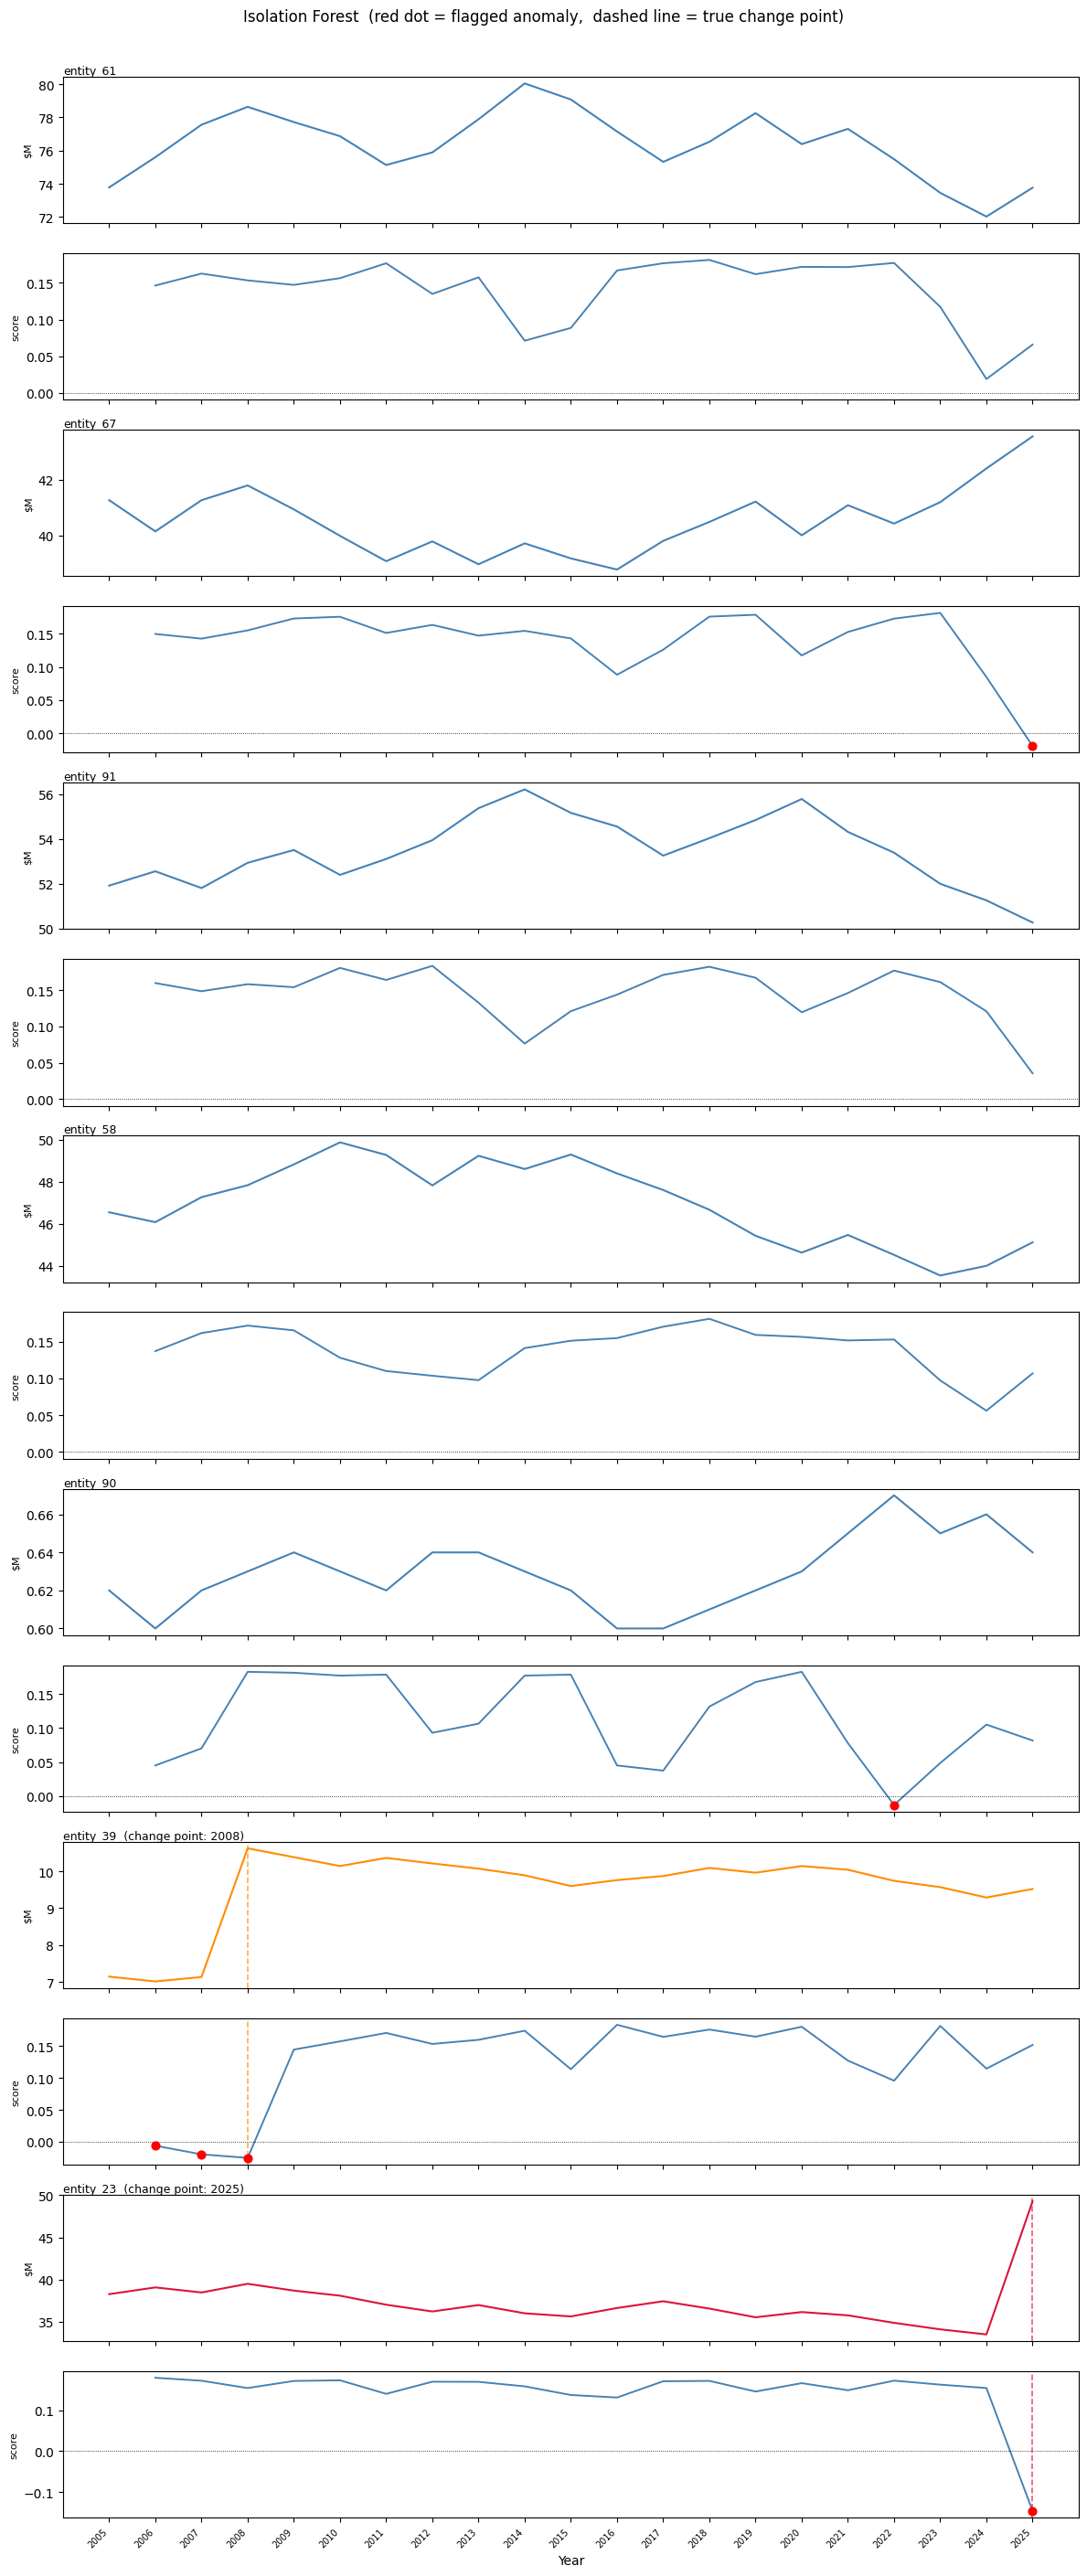

In [33]:
# Helper used by both Section 2 and Section 3.
# For each entity in sample_ids, draws two stacked panels:
#   top    — original budget over time
#   bottom — anomaly score, with flagged years as red dots
def plot_with_scores(score_col, flag_col, ref_line, title):
    n = len(sample_ids)
    fig, axes = plt.subplots(n * 2, 1, figsize=(12, 4 * n), sharex=True)

    for i, eid in enumerate(sample_ids):
        budget = df[df.entity_id == eid]    # all 21 years, from the original data
        scores = feat[feat.entity_id == eid]  # 20 years (2006–2025), has the model scores

        has_cp = scores.has_change_point.iloc[0]
        cp_yr  = scores.change_year.iloc[0]   # NaN if no change point

        color = "steelblue"
        if has_cp:
            color = "crimson" if cp_yr == 2025 else "darkorange"

        ax_top = axes[2 * i]
        ax_bot = axes[2 * i + 1]

        # Top: original budget
        ax_top.plot(budget.year, budget.budget_millions, color=color, lw=1.5)
        ax_top.set_ylabel("$M", fontsize=8)

        # Bottom: anomaly score
        ax_bot.plot(scores.year, scores[score_col], color="steelblue", lw=1.4)
        ax_bot.axhline(ref_line, color="black", lw=0.6, ls=":")
        ax_bot.set_ylabel("score", fontsize=8)

        # Red dots for flagged years
        flagged = scores[scores[flag_col] == -1]
        ax_bot.scatter(flagged.year, flagged[score_col], color="red", zorder=5, s=40)

        # Dashed line at the true change point on both panels
        if has_cp:
            ax_top.axvline(cp_yr, color=color, lw=1.2, ls="--", alpha=0.7)
            ax_bot.axvline(cp_yr, color=color, lw=1.2, ls="--", alpha=0.7)
            ax_top.set_title(f"{eid}  (change point: {int(cp_yr)})", fontsize=9, loc="left", pad=2)
        else:
            ax_top.set_title(eid, fontsize=9, loc="left", pad=2)

    axes[-1].set_xlabel("Year")
    axes[-1].set_xticks(YEARS)
    plt.setp(axes[-1].get_xticklabels(), rotation=45, ha="right", fontsize=7)
    fig.suptitle(title, y=1.005)
    plt.tight_layout()
    plt.show()


# --- Step 4: Visualise ---
plot_with_scores(
    score_col="if_score", flag_col="if_flag", ref_line=0,
    title="Isolation Forest  (red dot = flagged anomaly,  dashed line = true change point)"
)

## Section 3: Local Outlier Factor

**Local Outlier Factor** measures how isolated a point is relative to its *local neighborhood* — it compares a point's density to the density of its k nearest neighbors. A point surrounded by dense neighbors but sitting in a sparse region gets a high LOF score.

Key difference from Isolation Forest: LOF is **density-based** and **local** — it can catch anomalies that are only unusual relative to nearby points, not necessarily global extremes. This makes it better at detecting subtle shifts in sparse regions of the feature space, but more sensitive to the choice of `n_neighbors`.

We run it on the same features and same 7 sample series for a direct comparison.

In [34]:
from sklearn.neighbors import LocalOutlierFactor

# Fit LOF on the same feature matrix used by Isolation Forest.
# n_neighbors=20: each point is compared against its 20 nearest neighbors.
# contamination matches IF so the comparison is fair.

model_lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
lof_labels = model_lof.fit_predict(features)  # -1 = anomaly, 1 = normal

feat["lof_score"] = model_lof.negative_outlier_factor_  # more negative = more anomalous
feat["lof_flag"]  = lof_labels

print(f"Flagged {(feat.lof_flag == -1).sum()} anomalies out of {len(feat)} observations")
print()
print("Did LOF find the planted change points?")
for _, row in meta[meta.has_change_point].iterrows():
    cp_yr = int(row.change_year)
    match = feat[(feat.entity_id == row.entity_id) & (feat.year == cp_yr)]
    if len(match) > 0:
        found = "✓ yes" if match.iloc[0].lof_flag == -1 else "✗ no"
        print(f"  {row.entity_id}  year={cp_yr}  {found}")

Flagged 20 anomalies out of 2000 observations

Did LOF find the planted change points?
  entity_23  year=2025  ✓ yes
  entity_39  year=2008  ✓ yes
  entity_56  year=2025  ✓ yes
  entity_82  year=2025  ✓ yes
  entity_86  year=2018  ✓ yes


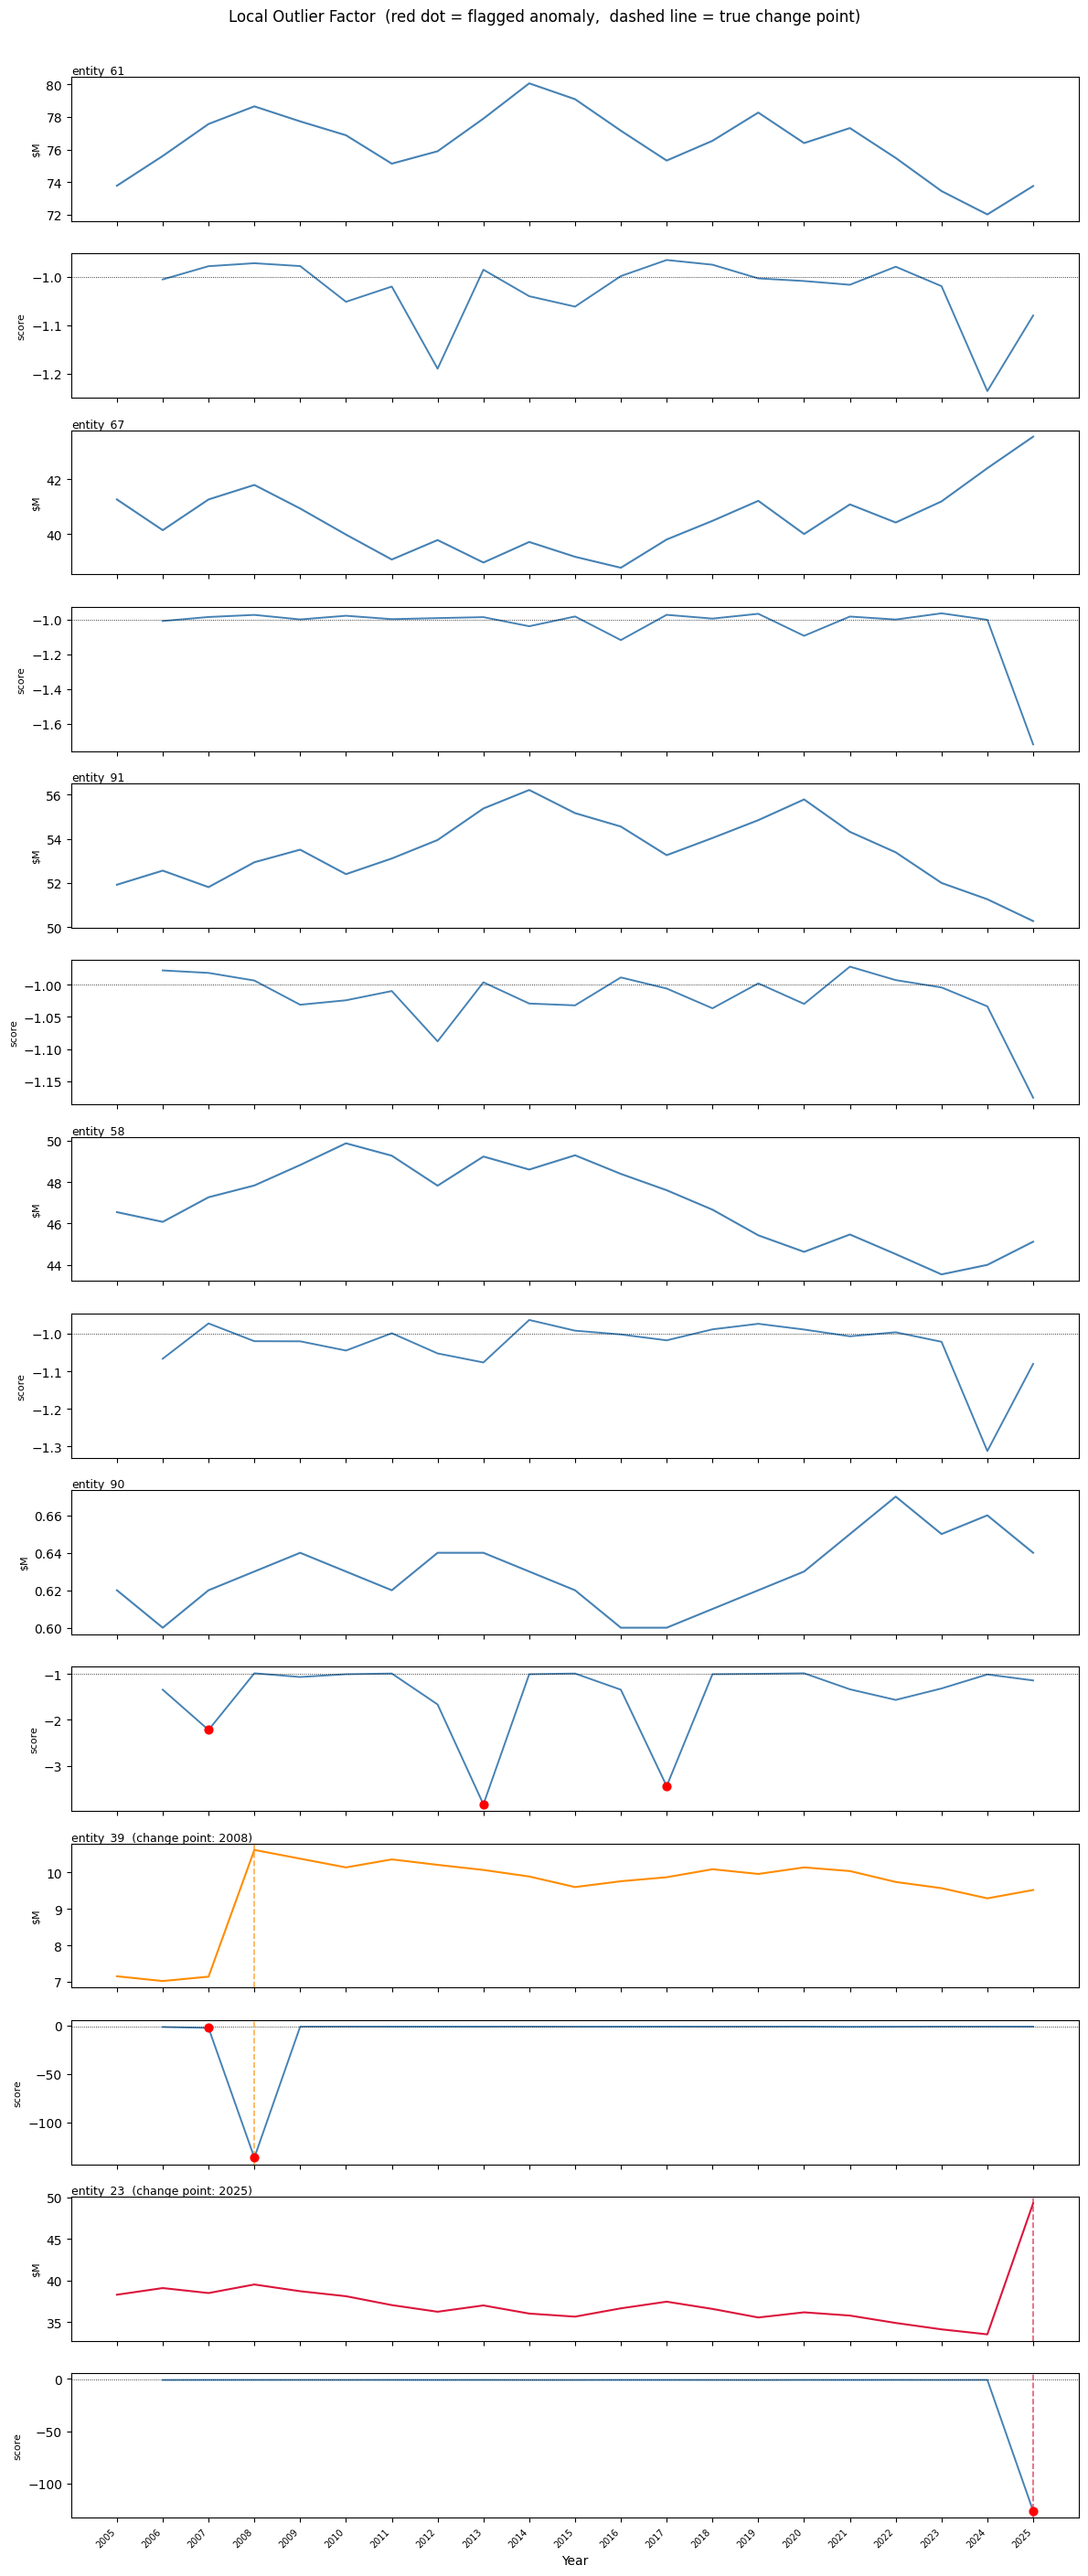

In [35]:
plot_with_scores(
    score_col="lof_score", flag_col="lof_flag", ref_line=-1,
    title="Local Outlier Factor  (red dot = flagged anomaly,  dashed line = true change point)"
)